# Hyperparameter Tuning — XGBoost with Optuna

In [3]:
# ── Colab Setup ──────────────────────────────────────────────────────────────
import os, sys, shutil

# 1. Clone the repo
!git clone https://github.com/Milica206001/power_price_prediction.git
os.chdir('/content/power_price_prediction')
sys.path.insert(0, os.getcwd())

# 2. Mount Google Drive (where your data CSVs are stored)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# 3. Copy data from Drive into artifact/ folder
# Update the Drive path below to match where you uploaded the CSVs
DRIVE_DATA_PATH = '/content/drive/MyDrive/power_price_data'
os.makedirs('artifact', exist_ok=True)
shutil.copy(f'{DRIVE_DATA_PATH}/train.csv', 'artifact/train.csv')
shutil.copy(f'{DRIVE_DATA_PATH}/test.csv',  'artifact/test.csv')

# 4. Install dependencies
!pip install -q optuna dill category_encoders xgboost catboost scikit-learn

print('Setup complete!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00:00:0100:01m
Setup complete!


In [5]:
import os
import sys
import dill
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from src.utils import evaluate_models
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root: {project_root}')

Project root: /content/power_price_prediction


In [6]:
import sys
print(sys.executable)

import subprocess
result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'optuna'], capture_output=True, text=True)
print(result.stdout or result.stderr)


/usr/bin/python3
Name: optuna
Version: 4.8.0
Summary: A hyperparameter optimization framework
Home-page: https://optuna.org/
Author: Takuya Akiba
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: alembic, colorlog, numpy, packaging, PyYAML, sqlalchemy, tqdm
Required-by: 



## 1. Load & Transform Data

In [7]:
from src.components.data_transformation import DataTransformation

train_path = os.path.join(project_root, 'artifact', 'train.csv')
test_path  = os.path.join(project_root, 'artifact', 'test.csv')

transformation = DataTransformation()
train_arr, test_arr, _ = transformation.initiate_data_transformation(train_path, test_path)

X_train, y_train = train_arr[:, :-1], train_arr[:, -1]
X_test,  y_test  = test_arr[:, :-1],  test_arr[:, -1]

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

X_train: (2400710, 96)  |  X_test: (600178, 96)


## 2. Optuna Hyperparameter Search

In [33]:
def objective(trial):
    params = {
        'device': 'cuda', 
        'n_estimators':     trial.suggest_int('n_estimators', 100,800), 
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1.0, 4.0),
        'random_state':     42,
        'early_stopping_rounds': 50 
    }

    model = XGBRegressor(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False 
    )

    y_pred = model.predict(X_test)
    return r2_score(y_test, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'\nBest R2  : {study.best_value:.4f}')
print(f'Best params:\n{study.best_params}')

  0%|          | 0/20 [00:00<?, ?it/s]


Best R2  : 0.9330
Best params:
{'n_estimators': 608, 'max_depth': 6, 'learning_rate': 0.18650184445032772, 'subsample': 0.9022219658106048, 'min_child_weight': 9, 'gamma': 0.1254465925630504, 'reg_alpha': 0.8125595649699908, 'reg_lambda': 3.323459485732273}


## 3. Train Best Model & Evaluate

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

tuned_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)
tuned_model.fit(X_train, y_train)
pred = tuned_model.predict(X_test)

print(f'R2  : {r2_score(y_test, pred):.4f}')
print(f'MAE : {mean_absolute_error(y_test, pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.4f}')

R2  : 0.9330
MAE : 77.4144
RMSE: 283.3239


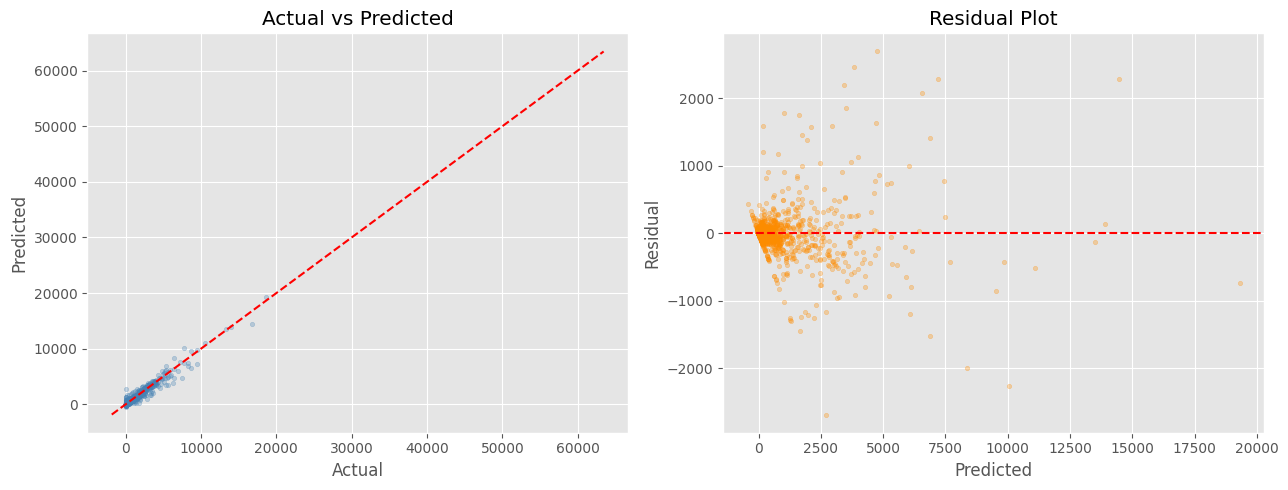

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample_idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[0].scatter(y_test[sample_idx], pred[sample_idx], alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set(xlabel='Actual', ylabel='Predicted', title='Actual vs Predicted')

residuals = y_test[sample_idx] - pred[sample_idx]
axes[1].scatter(pred[sample_idx], residuals, alpha=0.3, s=10, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set(xlabel='Predicted', ylabel='Residual', title='Residual Plot')

plt.tight_layout()
plt.show()

## 4. Optuna Visualizations

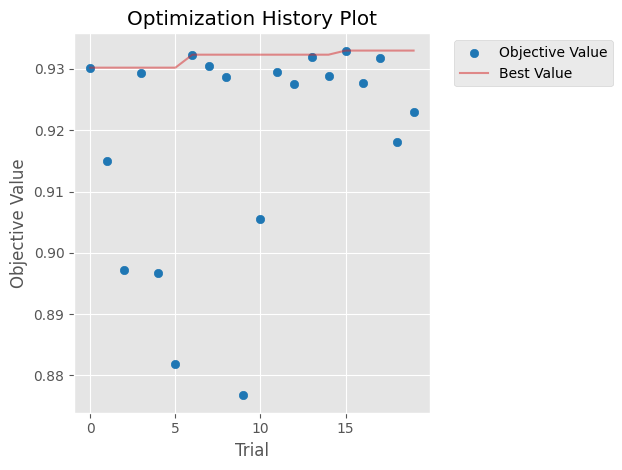

In [36]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.show()

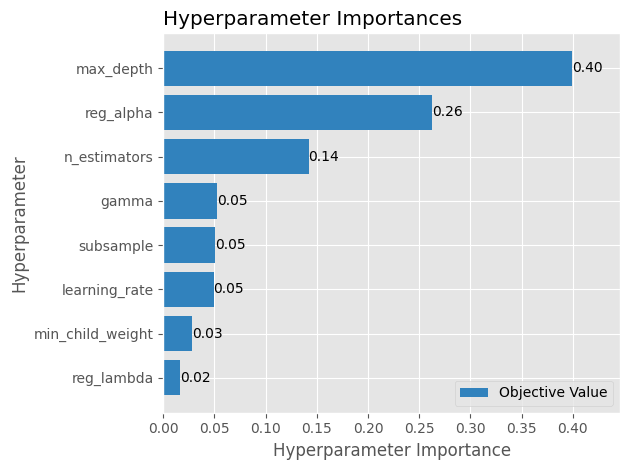

In [37]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()

## 5. Feature Importances

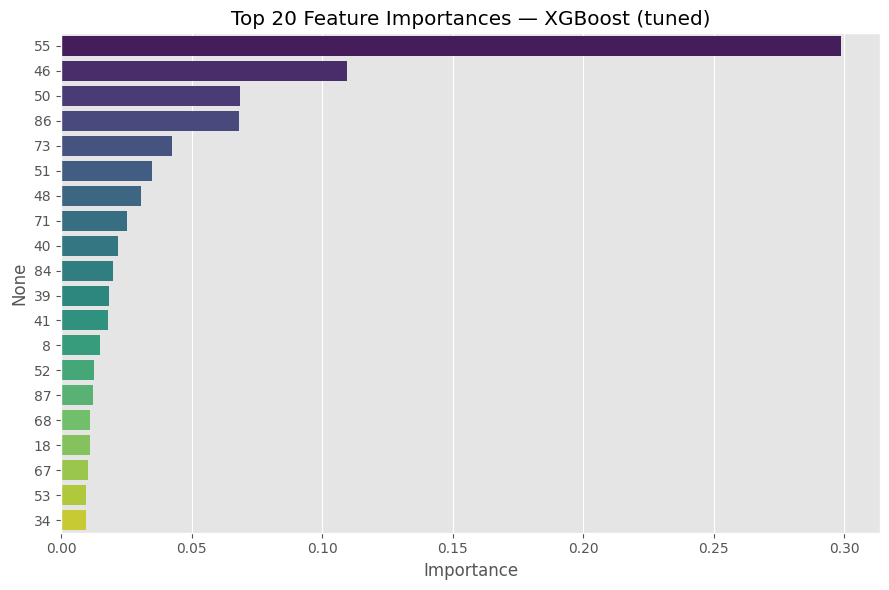

In [38]:
fi = pd.Series(tuned_model.feature_importances_).sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 6))
sns.barplot(x=fi.values, y=fi.index.astype(str), palette='viridis', orient='h')
plt.title('Top 20 Feature Importances — XGBoost (tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Save Tuned Model

In [24]:
output_path = os.path.join(project_root, 'artifact', 'model_tuned.pkl')
with open(output_path, 'wb') as f:
    dill.dump(tuned_model, f)

print(f'Saved to: {output_path}')

Saved to: /content/power_price_prediction/artifact/model_tuned.pkl


In [39]:
source = '/content/power_price_prediction/artifact/model_tuned.pkl'
destination = '/content/drive/MyDrive/model_tuned.pkl'

shutil.copy(source, destination)
print("Check your Google Drive on the web now!")

Check your Google Drive on the web now!
